# Diagnosing "Separated but Not Linearly Decodable" in Cat 5

Based on the results in `visualize_probe.ipynb`, we observed:
1. High prediction error (nRMSE > 4) for extreme intensity categories (Cat 5, Cat 4)
2. Evidence of representation collapse in extreme regimes (lower variance, effective dimensionality)
3. Strong correlation between representation quality and prediction error

**Key Question:** Is the poor performance due to:
- (A) Label-irrelevant separation in representation space (nuisance factors dominate)
- (B) Nonlinear encoding of labels (linear probe is insufficient)
- (C) Data imbalance from training on full dataset (global imbalance issue)

## Diagnostics

1. **Within-bin signal plot (Cat 5 only)**: Does feature distance correlate with label difference?
2. **Local linearity test (Cat 5 only)**: Does ridge regression work when trained only on Cat 5?
3. **Nonlinear probe sanity check (Cat 5 only)**: Does kernel ridge regression recover the signal?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_from_disk
from sklearn.linear_model import RidgeCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Configuration

In [2]:
# Models to evaluate
MODELS_TO_EVALUATE = [
    {
        "name": "DINOv3",
        "feature_dataset": "/nfs/scistore19/locatgrp/dyao/DATA/cyclones/features_dinov3",
    },
    {
        "name": "CLIP",
        "feature_dataset": "/nfs/scistore19/locatgrp/dyao/DATA/cyclones/features_clip",
    },
    {
        "name": "MAE",
        "feature_dataset": "/nfs/scistore19/locatgrp/dyao/DATA/cyclones/features_mae",
    },
]

# Cat 5 definition: pressure < 920 mb
CAT5_PRESSURE_THRESHOLD = 920

## Data Loading

In [3]:
def load_all_data(dataset_path: Path):
    """Load all splits (train, val, test) features and targets."""
    print(f"Loading data from {dataset_path}...")
    dataset = load_from_disk(str(dataset_path))
    
    all_features = []
    all_pressure = []
    all_wind = []
    all_split = []
    
    for split_name in ['train', 'validation', 'test']:
        if split_name not in dataset:
            continue
        split_data = dataset[split_name]
        print(f"  Extracting {split_name} ({len(split_data)} cyclones)...")
        
        for example in tqdm(split_data, desc=f"  {split_name}"):
            features = np.array(example['features'])  # (T, D)
            pressure = np.array(example['pressure'])  # (T,)
            wind = np.array(example['wind'])  # (T,)
            T = len(pressure)
            all_features.extend(features[:T])
            all_pressure.extend(pressure[:T])
            all_wind.extend(wind[:T])
            all_split.extend([split_name] * T)
    
    X = np.array(all_features)
    pressure = np.array(all_pressure)
    wind = np.array(all_wind)
    split = np.array(all_split)
    
    # Remove NaN values
    valid_mask = ~(np.isnan(pressure) | np.isnan(wind) | np.any(np.isnan(X), axis=1))
    X = X[valid_mask]
    pressure = pressure[valid_mask]
    wind = wind[valid_mask]
    split = split[valid_mask]
    
    print(f"  Total: {X.shape[0]:,} frames, {X.shape[1]} features")
    
    return X, pressure, wind, split


def extract_cat5_data(X, pressure, wind, split, threshold=CAT5_PRESSURE_THRESHOLD):
    """Extract only Cat 5 samples (pressure < threshold)."""
    cat5_mask = pressure < threshold
    
    X_cat5 = X[cat5_mask]
    pressure_cat5 = pressure[cat5_mask]
    wind_cat5 = wind[cat5_mask]
    split_cat5 = split[cat5_mask]
    
    print(f"  Cat 5 samples: {len(X_cat5)} ({100*len(X_cat5)/len(X):.2f}% of total)")
    print(f"  Pressure range: [{pressure_cat5.min():.1f}, {pressure_cat5.max():.1f}] mb")
    print(f"  Wind range: [{wind_cat5.min():.1f}, {wind_cat5.max():.1f}] kts")
    
    return X_cat5, pressure_cat5, wind_cat5, split_cat5

In [4]:
# Load data for all models
model_data = {}

for model_config in MODELS_TO_EVALUATE:
    model_name = model_config["name"]
    dataset_path = Path(model_config["feature_dataset"])
    
    if not dataset_path.exists():
        print(f"Dataset not found: {dataset_path}")
        continue
    
    print(f"\n{'='*60}")
    print(f"Loading: {model_name}")
    print(f"{'='*60}")
    
    X, pressure, wind, split = load_all_data(dataset_path)
    X_cat5, pressure_cat5, wind_cat5, split_cat5 = extract_cat5_data(X, pressure, wind, split)
    
    model_data[model_name] = {
        "X_all": X,
        "pressure_all": pressure,
        "wind_all": wind,
        "split_all": split,
        "X_cat5": X_cat5,
        "pressure_cat5": pressure_cat5,
        "wind_cat5": wind_cat5,
        "split_cat5": split_cat5,
    }


Loading: DINOv3
Loading data from /nfs/scistore19/locatgrp/dyao/DATA/cyclones/features_dinov3...
  Extracting train (2598 cyclones)...


  train: 100%|██████████| 2598/2598 [01:01<00:00, 42.13it/s]


  Extracting validation (325 cyclones)...


  validation: 100%|██████████| 325/325 [00:07<00:00, 41.74it/s]


  Extracting test (325 cyclones)...


...

  Extracting validation (325 cyclones)...


  validation: 100%|██████████| 325/325 [00:07<00:00, 42.06it/s]


  Extracting test (325 cyclones)...


  test: 100%|██████████| 325/325 [00:07<00:00, 44.65it/s]


  Total: 179,882 frames, 768 features
  Cat 5 samples: 1469 (0.82% of total)
  Pressure range: [872.0, 919.0] mb
  Wind range: [80.0, 185.0] kts


---
## Diagnostic 1: Within-bin Signal Plot (Cat 5 Only)

For Cat 5 samples, draw random pairs $(i, j)$ and plot:
- **x-axis:** $\| z_i - z_j \|$ (feature distance)
- **y-axis:** $| y_i - y_j |$ (label difference)

**Interpretation:**
- If $\|z_i - z_j\|$ varies widely but $|y_i - y_j|$ shows little variation or weak correlation,
  the separation in representation space is largely **label-irrelevant** (dominated by nuisance factors).
- Strong positive correlation suggests the representation preserves label-relevant information.

In [5]:
def compute_pairwise_distances_and_label_diffs(X, y, n_pairs=5000, seed=42):
    """Compute feature distances and label differences for random pairs."""
    np.random.seed(seed)
    n = len(X)
    
    # Sample random pairs
    idx_i = np.random.randint(0, n, size=n_pairs)
    idx_j = np.random.randint(0, n, size=n_pairs)
    
    # Ensure i != j
    while np.any(idx_i == idx_j):
        same_mask = idx_i == idx_j
        idx_j[same_mask] = np.random.randint(0, n, size=same_mask.sum())
    
    # Compute distances and differences
    feature_dists = np.linalg.norm(X[idx_i] - X[idx_j], axis=1)
    label_diffs = np.abs(y[idx_i] - y[idx_j])
    
    return feature_dists, label_diffs

Diagnostic 1: Within-bin Signal Plot (Cat 5 Only)

DINOv3:
  Pressure: Pearson r = -0.016, Spearman r = -0.021
  Wind:     Pearson r = -0.063, Spearman r = -0.011

CLIP:
  Pressure: Pearson r = 0.037, Spearman r = 0.026
  Wind:     Pearson r = -0.037, Spearman r = -0.003

MAE:
  Pressure: Pearson r = -0.005, Spearman r = -0.007
  Wind:     Pearson r = -0.017, Spearman r = -0.005


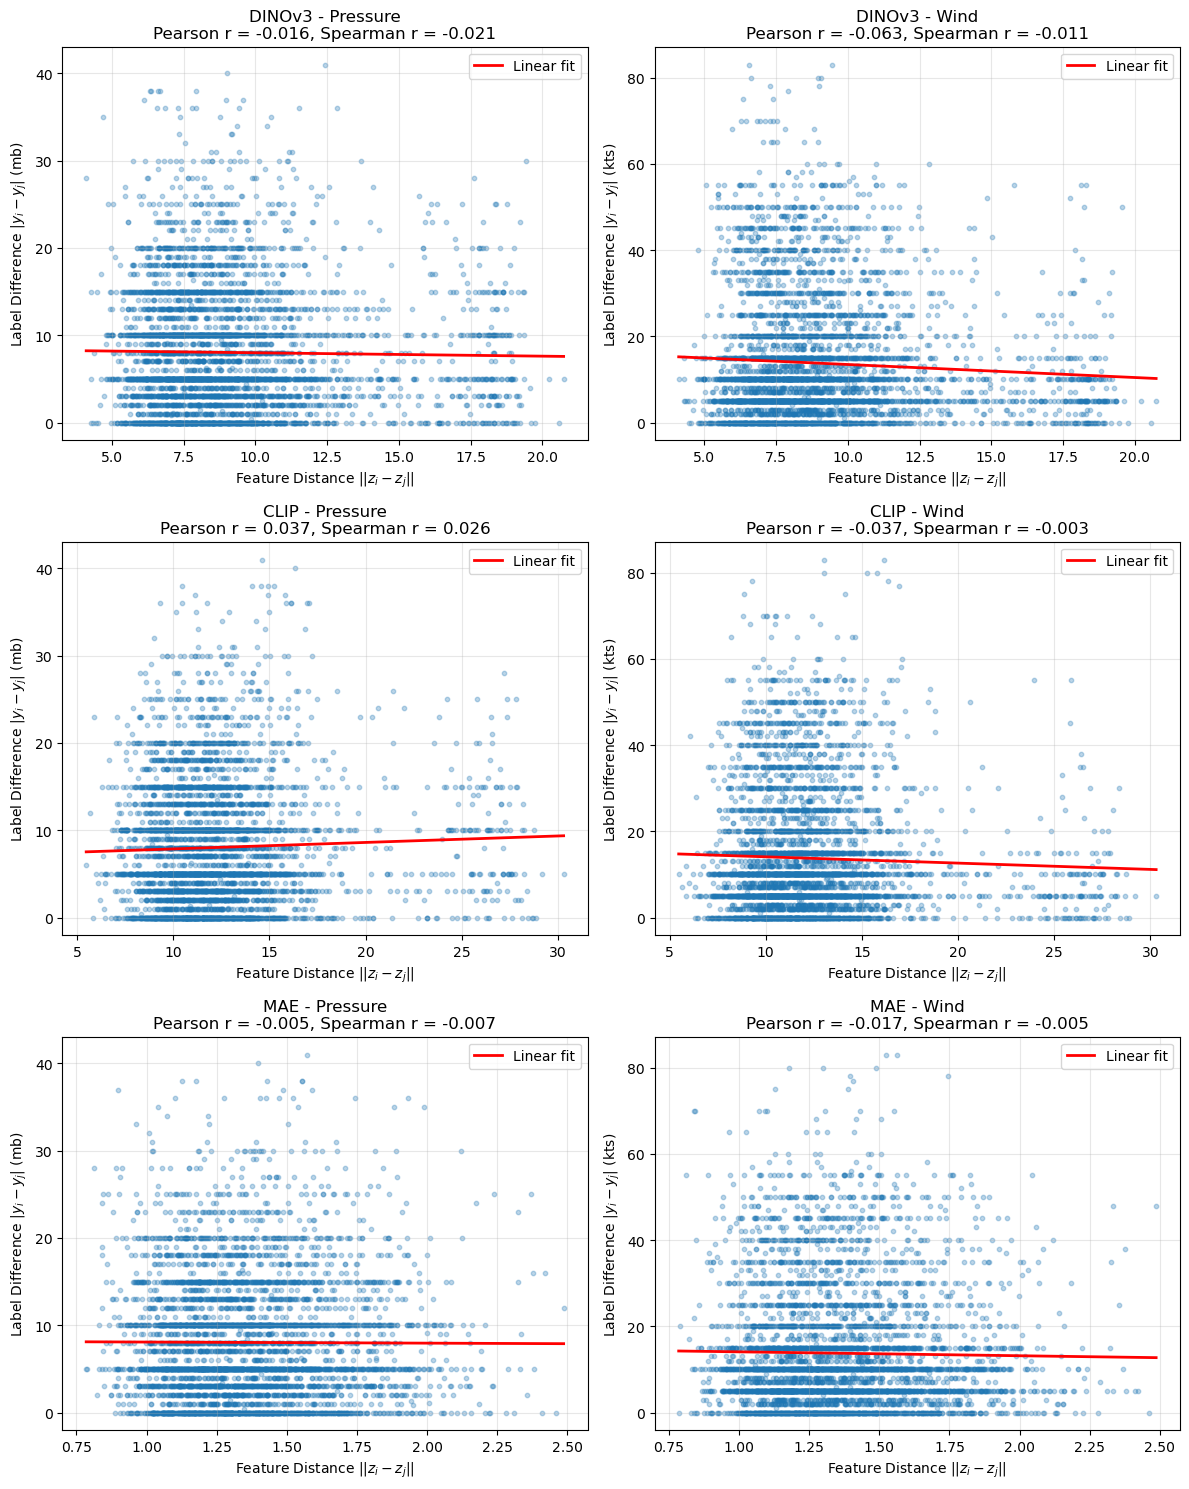


Interpretation:
- r ~ 0: Feature distance does NOT predict label difference (label-irrelevant separation)
- r > 0.3: Feature distance positively correlates with label difference (label-relevant)
- r < 0: Samples far apart in feature space are similar in labels (inverted mapping)


In [6]:
from scipy.stats import pearsonr, spearmanr

n_models = len(model_data)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)

print("Diagnostic 1: Within-bin Signal Plot (Cat 5 Only)")
print("="*70)

for i, (model_name, data) in enumerate(model_data.items()):
    X_cat5 = data["X_cat5"]
    pressure_cat5 = data["pressure_cat5"]
    wind_cat5 = data["wind_cat5"]
    
    print(f"\n{model_name}:")
    
    # Pressure
    feat_dists_p, label_diffs_p = compute_pairwise_distances_and_label_diffs(
        X_cat5, pressure_cat5, n_pairs=min(5000, len(X_cat5) * (len(X_cat5) - 1) // 2)
    )
    r_pearson_p, _ = pearsonr(feat_dists_p, label_diffs_p)
    r_spearman_p, _ = spearmanr(feat_dists_p, label_diffs_p)
    print(f"  Pressure: Pearson r = {r_pearson_p:.3f}, Spearman r = {r_spearman_p:.3f}")
    
    ax = axes[i, 0]
    ax.scatter(feat_dists_p, label_diffs_p, alpha=0.3, s=10)
    ax.set_xlabel("Feature Distance $||z_i - z_j||$")
    ax.set_ylabel("Label Difference $|y_i - y_j|$ (mb)")
    ax.set_title(f"{model_name} - Pressure\nPearson r = {r_pearson_p:.3f}, Spearman r = {r_spearman_p:.3f}")
    ax.grid(alpha=0.3)
    
    # Fit a linear trend line
    z = np.polyfit(feat_dists_p, label_diffs_p, 1)
    p = np.poly1d(z)
    x_line = np.linspace(feat_dists_p.min(), feat_dists_p.max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2, label='Linear fit')
    ax.legend()
    
    # Wind
    feat_dists_w, label_diffs_w = compute_pairwise_distances_and_label_diffs(
        X_cat5, wind_cat5, n_pairs=min(5000, len(X_cat5) * (len(X_cat5) - 1) // 2)
    )
    r_pearson_w, _ = pearsonr(feat_dists_w, label_diffs_w)
    r_spearman_w, _ = spearmanr(feat_dists_w, label_diffs_w)
    print(f"  Wind:     Pearson r = {r_pearson_w:.3f}, Spearman r = {r_spearman_w:.3f}")
    
    ax = axes[i, 1]
    ax.scatter(feat_dists_w, label_diffs_w, alpha=0.3, s=10)
    ax.set_xlabel("Feature Distance $||z_i - z_j||$")
    ax.set_ylabel("Label Difference $|y_i - y_j|$ (kts)")
    ax.set_title(f"{model_name} - Wind\nPearson r = {r_pearson_w:.3f}, Spearman r = {r_spearman_w:.3f}")
    ax.grid(alpha=0.3)
    
    # Fit a linear trend line
    z = np.polyfit(feat_dists_w, label_diffs_w, 1)
    p = np.poly1d(z)
    x_line = np.linspace(feat_dists_w.min(), feat_dists_w.max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2, label='Linear fit')
    ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Interpretation:")
print("- r ~ 0: Feature distance does NOT predict label difference (label-irrelevant separation)")
print("- r > 0.3: Feature distance positively correlates with label difference (label-relevant)")
print("- r < 0: Samples far apart in feature space are similar in labels (inverted mapping)")

---
## Diagnostic 2: Local Linearity Test (Cat 5 Only)

Train and evaluate a ridge regressor **using only Cat 5 data**:
- Perform a train/validation split *within Cat 5*.
- Tune the regularization strength on Cat 5 validation data.

**Interpretation:**
- If performance remains poor, the mapping $y = w^\top z$ is **nonlinear, noisy, or saturated** in this regime (not a global imbalance issue).
- If performance improves significantly compared to global ridge, the issue is **data imbalance** during training.

In [7]:
def evaluate_ridge_on_cat5(X_cat5, y_cat5, target_name="pressure", test_size=0.3, seed=42):
    """Train and evaluate ridge regression on Cat 5 data only."""
    
    # Split Cat 5 data into train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_cat5, y_cat5, test_size=test_size, random_state=seed
    )
    
    print(f"  {target_name.capitalize()}:")
    print(f"    Train: {len(X_train)}, Val: {len(X_val)}")
    print(f"    Label range (train): [{y_train.min():.1f}, {y_train.max():.1f}]")
    print(f"    Label std (train): {y_train.std():.2f}")
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Train Ridge with cross-validation for alpha selection
    alphas = np.logspace(-4, 4, 20)
    ridge = RidgeCV(alphas=alphas, cv=5)
    ridge.fit(X_train_scaled, y_train)
    
    print(f"    Best alpha: {ridge.alpha_:.4f}")
    
    # Evaluate on validation set
    y_pred = ridge.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    nrmse = rmse / y_val.std() if y_val.std() > 0 else np.nan
    
    print(f"    RMSE: {rmse:.2f}")
    print(f"    nRMSE (RMSE/std): {nrmse:.3f}")
    print(f"    R^2: {r2:.3f}")
    
    return {
        "model": ridge,
        "scaler": scaler,
        "y_val": y_val,
        "y_pred": y_pred,
        "rmse": rmse,
        "nrmse": nrmse,
        "r2": r2,
        "best_alpha": ridge.alpha_,
    }

In [8]:
print("Diagnostic 2: Local Linearity Test (Cat 5 Only)")
print("="*70)

local_ridge_results = {}

for model_name, data in model_data.items():
    X_cat5 = data["X_cat5"]
    pressure_cat5 = data["pressure_cat5"]
    wind_cat5 = data["wind_cat5"]
    
    print(f"\n{model_name}:")
    print(f"  Cat 5 samples: {len(X_cat5)}")
    
    pressure_result = evaluate_ridge_on_cat5(X_cat5, pressure_cat5, "pressure")
    wind_result = evaluate_ridge_on_cat5(X_cat5, wind_cat5, "wind")
    
    local_ridge_results[model_name] = {
        "pressure": pressure_result,
        "wind": wind_result,
    }

Diagnostic 2: Local Linearity Test (Cat 5 Only)

DINOv3:
  Cat 5 samples: 1469
  Pressure:
    Train: 1028, Val: 441
    Label range (train): [872.0, 919.0]
    Label std (train): 7.46
    Best alpha: 545.5595
    RMSE: 6.65
    nRMSE (RMSE/std): 0.919
    R^2: 0.155
  Wind:
    Train: 1028, Val: 441
    Label range (train): [80.0, 185.0]
    Label std (train): 14.14
    Best alpha: 206.9138
    RMSE: 10.76
    nRMSE (RMSE/std): 0.822
    R^2: 0.324

CLIP:
  Cat 5 samples: 1469
  Pressure:
    Train: 1028, Val: 441
    Label range (train): [872.0, 919.0]
    Label std (train): 7.46
    Best alpha: 545.5595
    RMSE: 6.62
    nRMSE (RMSE/std): 0.914
    R^2: 0.164
  Wind:
    Train: 1028, Val: 441
    Label range (train): [80.0, 185.0]
    Label std (train): 14.14
    Best alpha: 206.9138
    RMSE: 11.61
    nRMSE (RMSE/std): 0.887
    R^2: 0.212

MAE:
  Cat 5 samples: 1469
  Pressure:
    Train: 1028, Val: 441
    Label range (train): [872.0, 919.0]
    Label std (train): 7.46
    Best

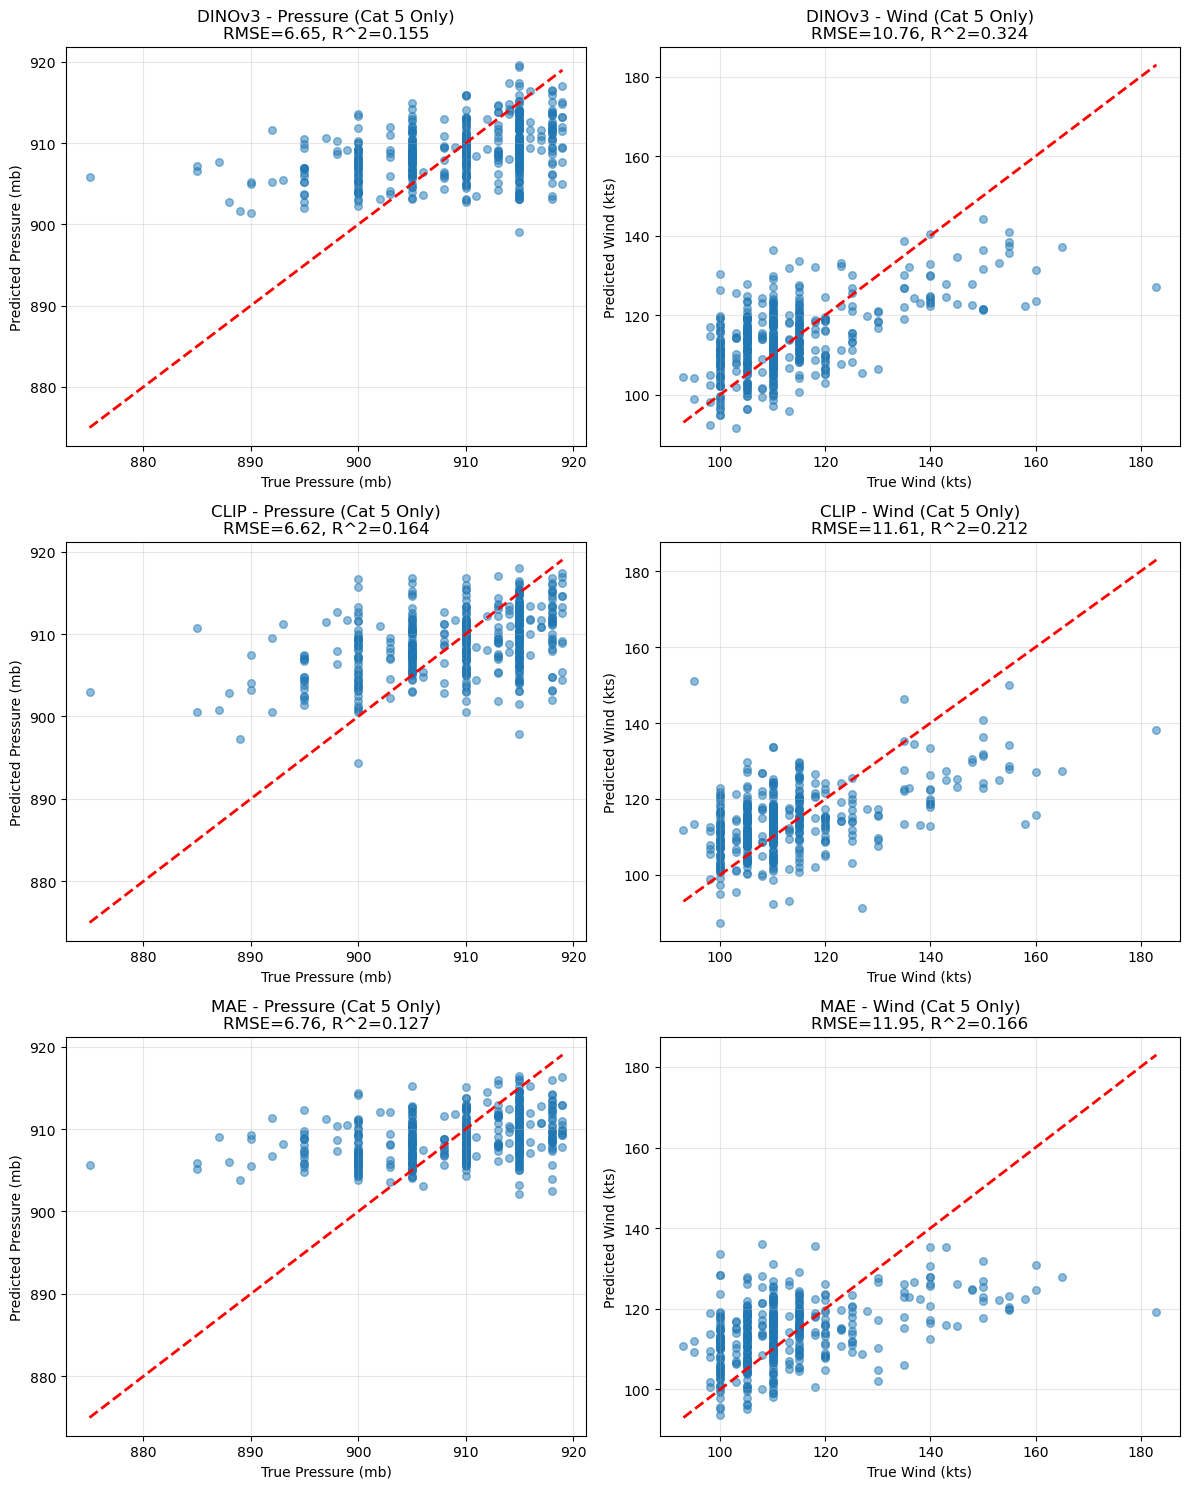


Interpretation:
- nRMSE > 1: Model performs worse than predicting the mean (very poor)
- nRMSE ~ 1: Model is about as good as predicting the mean
- nRMSE < 1: Model captures some variance in the labels
- R^2 < 0: Model performs worse than predicting the mean


In [9]:
# Scatter plots: Predicted vs True for local ridge
n_models = len(local_ridge_results)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)

for i, (model_name, results) in enumerate(local_ridge_results.items()):
    # Pressure
    y_val_p = results["pressure"]["y_val"]
    y_pred_p = results["pressure"]["y_pred"]
    rmse_p = results["pressure"]["rmse"]
    r2_p = results["pressure"]["r2"]
    
    ax = axes[i, 0]
    ax.scatter(y_val_p, y_pred_p, alpha=0.5, s=30)
    ax.plot([y_val_p.min(), y_val_p.max()], [y_val_p.min(), y_val_p.max()], 'r--', lw=2)
    ax.set_xlabel("True Pressure (mb)")
    ax.set_ylabel("Predicted Pressure (mb)")
    ax.set_title(f"{model_name} - Pressure (Cat 5 Only)\nRMSE={rmse_p:.2f}, R^2={r2_p:.3f}")
    ax.grid(alpha=0.3)
    
    # Wind
    y_val_w = results["wind"]["y_val"]
    y_pred_w = results["wind"]["y_pred"]
    rmse_w = results["wind"]["rmse"]
    r2_w = results["wind"]["r2"]
    
    ax = axes[i, 1]
    ax.scatter(y_val_w, y_pred_w, alpha=0.5, s=30)
    ax.plot([y_val_w.min(), y_val_w.max()], [y_val_w.min(), y_val_w.max()], 'r--', lw=2)
    ax.set_xlabel("True Wind (kts)")
    ax.set_ylabel("Predicted Wind (kts)")
    ax.set_title(f"{model_name} - Wind (Cat 5 Only)\nRMSE={rmse_w:.2f}, R^2={r2_w:.3f}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- nRMSE > 1: Model performs worse than predicting the mean (very poor)")
print("- nRMSE ~ 1: Model is about as good as predicting the mean")
print("- nRMSE < 1: Model captures some variance in the labels")
print("- R^2 < 0: Model performs worse than predicting the mean")

---
## Diagnostic 3: Nonlinear Probe Sanity Check (Cat 5 Only)

Train a simple nonlinear model on Cat 5:
- Kernel ridge regression (e.g., RBF kernel)

**Interpretation:**
- If the nonlinear probe succeeds while ridge fails, the label is present but encoded **nonlinearly** in the representation (evidence against point collapse).
- If both linear and nonlinear probes fail, the representation truly lacks label-relevant information.

In [18]:
def evaluate_kernel_ridge_on_cat5(X_cat5, y_cat5, target_name="pressure", test_size=0.3, seed=42):
    """Train and evaluate kernel ridge regression on Cat 5 data only."""
    
    # Split Cat 5 data into train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_cat5, y_cat5, test_size=test_size, random_state=seed
    )
    
    print(f"  {target_name.capitalize()}:")
    print(f"    Train: {len(X_train)}, Val: {len(X_val)}")
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Grid search for kernel ridge with RBF kernel
    # Use a subset for grid search if data is large
    # if len(X_train_scaled) > 500:
    #     idx_subsample = np.random.choice(len(X_train_scaled), 500, replace=False)
    #     X_train_gs = X_train_scaled[idx_subsample]
    #     y_train_gs = y_train[idx_subsample]
    # else:
    # X_train_gs = X_train_scaled
    # y_train_gs = y_train
    
    param_grid = {
        'alpha': [0.01, 0.1, 1.0, 10.0],
        'gamma': [0.001, 0.01, 0.1, 1.0, 'scale'],
    }
    from sklearn.neural_network import MLPRegressor
    model = MLPRegressor(hidden_layer_sizes=(100,50), max_iter=500)
    
    # krr = KernelRidge(kernel='rbf')
    # grid_search = GridSearchCV(krr, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    # grid_search.fit(X_train_gs, y_train_gs)
    
    # print(f"    Best params: {grid_search.best_params_}")
    
    # # Retrain on full training data with best params
    # best_krr = KernelRidge(kernel='rbf', **grid_search.best_params_)
    # best_krr.fit(X_train_scaled, y_train)
    
    model.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_pred = model.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    nrmse = rmse / y_val.std() if y_val.std() > 0 else np.nan
    
    print(f"    RMSE: {rmse:.2f}")
    print(f"    nRMSE (RMSE/std): {nrmse:.3f}")
    print(f"    R^2: {r2:.3f}")
    
    return {
        # "model": best_krr,
        "scaler": scaler,
        "y_val": y_val,
        "y_pred": y_pred,
        "rmse": rmse,
        "nrmse": nrmse,
        "r2": r2,
        # "best_params": grid_search.best_params_,
    }

In [19]:
print("Diagnostic 3: Nonlinear Probe Sanity Check (Cat 5 Only)")
print("="*70)

kernel_ridge_results = {}

for model_name, data in model_data.items():
    X_cat5 = data["X_cat5"]
    pressure_cat5 = data["pressure_cat5"]
    wind_cat5 = data["wind_cat5"]
    
    print(f"\n{model_name}:")
    print(f"  Cat 5 samples: {len(X_cat5)}")
    
    pressure_result = evaluate_kernel_ridge_on_cat5(X_cat5, pressure_cat5, "pressure")
    wind_result = evaluate_kernel_ridge_on_cat5(X_cat5, wind_cat5, "wind")
    
    kernel_ridge_results[model_name] = {
        "pressure": pressure_result,
        "wind": wind_result,
    }

Diagnostic 3: Nonlinear Probe Sanity Check (Cat 5 Only)

DINOv3:
  Cat 5 samples: 1469
  Pressure:
    Train: 1028, Val: 441
    RMSE: 77.02
    nRMSE (RMSE/std): 10.643
    R^2: -112.280
  Wind:
    Train: 1028, Val: 441
    RMSE: 12.57
    nRMSE (RMSE/std): 0.961
    R^2: 0.077

CLIP:
  Cat 5 samples: 1469
  Pressure:
    Train: 1028, Val: 441
    RMSE: 62.94
    nRMSE (RMSE/std): 8.698
    R^2: -74.648
  Wind:
    Train: 1028, Val: 441
    RMSE: 12.62
    nRMSE (RMSE/std): 0.964
    R^2: 0.070

MAE:
  Cat 5 samples: 1469
  Pressure:
    Train: 1028, Val: 441
    RMSE: 107.73
    nRMSE (RMSE/std): 14.887
    R^2: -220.609
  Wind:
    Train: 1028, Val: 441
    RMSE: 16.96
    nRMSE (RMSE/std): 1.296
    R^2: -0.679


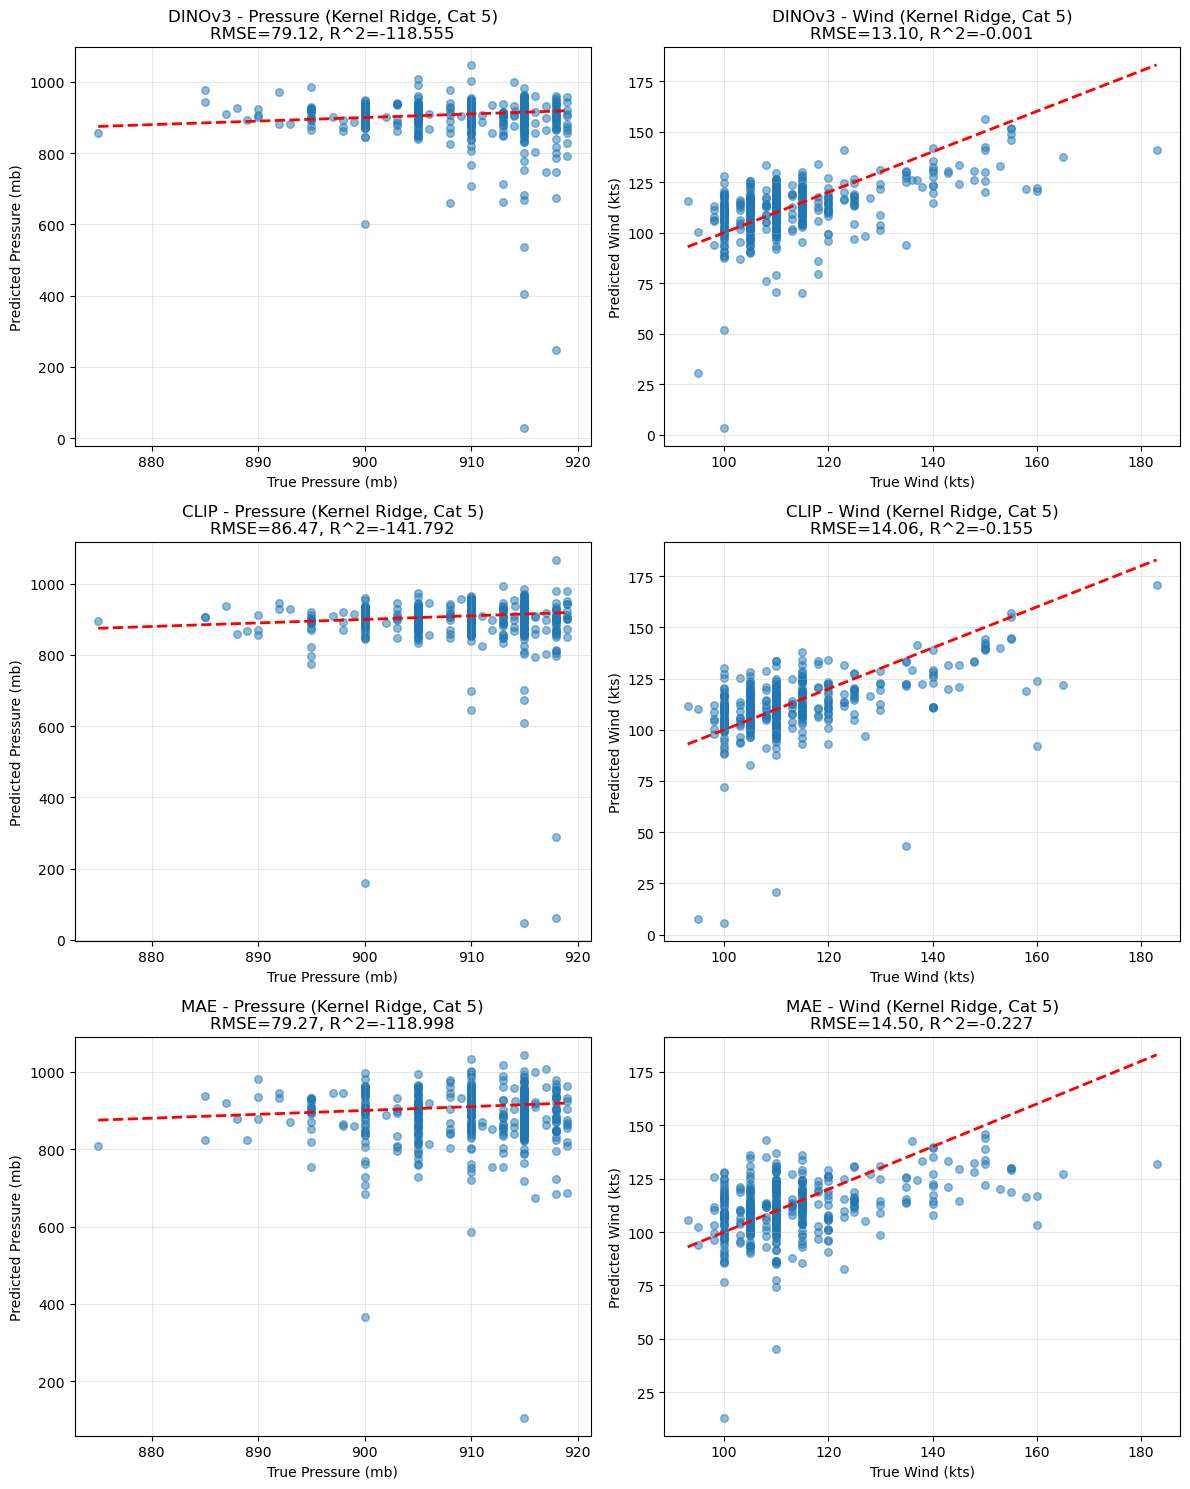

In [14]:
# Scatter plots: Predicted vs True for kernel ridge
n_models = len(kernel_ridge_results)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)

for i, (model_name, results) in enumerate(kernel_ridge_results.items()):
    # Pressure
    y_val_p = results["pressure"]["y_val"]
    y_pred_p = results["pressure"]["y_pred"]
    rmse_p = results["pressure"]["rmse"]
    r2_p = results["pressure"]["r2"]
    
    ax = axes[i, 0]
    ax.scatter(y_val_p, y_pred_p, alpha=0.5, s=30)
    ax.plot([y_val_p.min(), y_val_p.max()], [y_val_p.min(), y_val_p.max()], 'r--', lw=2)
    ax.set_xlabel("True Pressure (mb)")
    ax.set_ylabel("Predicted Pressure (mb)")
    ax.set_title(f"{model_name} - Pressure (Kernel Ridge, Cat 5)\nRMSE={rmse_p:.2f}, R^2={r2_p:.3f}")
    ax.grid(alpha=0.3)
    
    # Wind
    y_val_w = results["wind"]["y_val"]
    y_pred_w = results["wind"]["y_pred"]
    rmse_w = results["wind"]["rmse"]
    r2_w = results["wind"]["r2"]
    
    ax = axes[i, 1]
    ax.scatter(y_val_w, y_pred_w, alpha=0.5, s=30)
    ax.plot([y_val_w.min(), y_val_w.max()], [y_val_w.min(), y_val_w.max()], 'r--', lw=2)
    ax.set_xlabel("True Wind (kts)")
    ax.set_ylabel("Predicted Wind (kts)")
    ax.set_title(f"{model_name} - Wind (Kernel Ridge, Cat 5)\nRMSE={rmse_w:.2f}, R^2={r2_w:.3f}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary: Linear vs Nonlinear Probe Comparison

In [15]:
print("Summary: Linear vs Nonlinear Probe on Cat 5")
print("="*80)

summary_data = []

for model_name in model_data.keys():
    if model_name not in local_ridge_results or model_name not in kernel_ridge_results:
        continue
    
    for target in ["pressure", "wind"]:
        linear = local_ridge_results[model_name][target]
        nonlinear = kernel_ridge_results[model_name][target]
        
        summary_data.append({
            "Model": model_name,
            "Target": target.capitalize(),
            "Linear nRMSE": linear["nrmse"],
            "Linear R^2": linear["r2"],
            "Nonlinear nRMSE": nonlinear["nrmse"],
            "Nonlinear R^2": nonlinear["r2"],
            "Improvement": (linear["nrmse"] - nonlinear["nrmse"]) / linear["nrmse"] * 100 if linear["nrmse"] > 0 else 0,
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("Interpretation:")
print("-" * 80)
print("If Nonlinear nRMSE << Linear nRMSE (Improvement > 20%):")
print("  -> Label is encoded NONLINEARLY in the representation")
print("  -> Evidence AGAINST point collapse; representation has label-relevant structure")
print("")
print("If Nonlinear nRMSE ~ Linear nRMSE (Improvement < 10%):")
print("  -> Either labels are linearly decodable OR not decodable at all")
print("  -> If both nRMSE > 1: representation lacks label-relevant information")
print("  -> If both nRMSE < 1: linear probe is sufficient")

Summary: Linear vs Nonlinear Probe on Cat 5
 Model   Target  Linear nRMSE  Linear R^2  Nonlinear nRMSE  Nonlinear R^2  Improvement
DINOv3 Pressure      0.919468    0.154579        10.934111    -118.554789 -1089.178232
DINOv3     Wind      0.821937    0.324419         1.000709      -0.001419   -21.750069
  CLIP Pressure      0.914219    0.164204        11.949572    -141.792260 -1207.079671
  CLIP     Wind      0.887450    0.212433         1.074582      -0.154727   -21.086536
   MAE Pressure      0.934515    0.126682        10.954382    -118.998475 -1072.199658
   MAE     Wind      0.912978    0.166471         1.107759      -0.227131   -21.334723

Interpretation:
--------------------------------------------------------------------------------
If Nonlinear nRMSE << Linear nRMSE (Improvement > 20%):
  -> Label is encoded NONLINEARLY in the representation
  -> Evidence AGAINST point collapse; representation has label-relevant structure

If Nonlinear nRMSE ~ Linear nRMSE (Improvement < 10%):

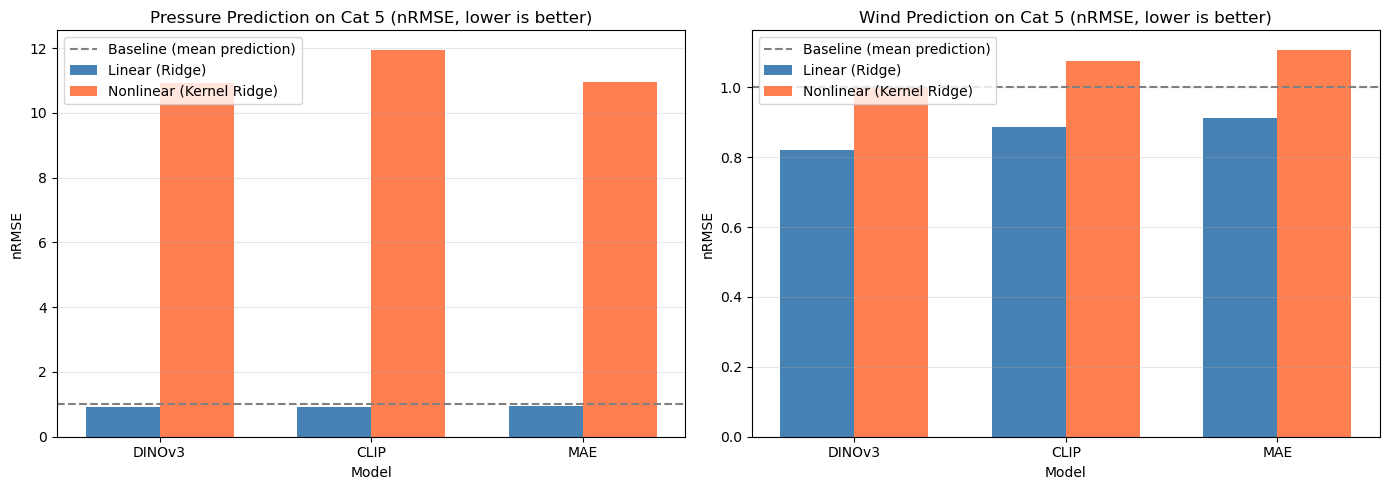

In [16]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(model_data.keys())
x = np.arange(len(models))
width = 0.35

# Pressure
ax = axes[0]
linear_nrmse_p = [local_ridge_results[m]["pressure"]["nrmse"] for m in models]
nonlinear_nrmse_p = [kernel_ridge_results[m]["pressure"]["nrmse"] for m in models]

ax.bar(x - width/2, linear_nrmse_p, width, label='Linear (Ridge)', color='steelblue')
ax.bar(x + width/2, nonlinear_nrmse_p, width, label='Nonlinear (Kernel Ridge)', color='coral')
ax.axhline(y=1.0, color='gray', linestyle='--', label='Baseline (mean prediction)')
ax.set_xlabel('Model')
ax.set_ylabel('nRMSE')
ax.set_title('Pressure Prediction on Cat 5 (nRMSE, lower is better)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Wind
ax = axes[1]
linear_nrmse_w = [local_ridge_results[m]["wind"]["nrmse"] for m in models]
nonlinear_nrmse_w = [kernel_ridge_results[m]["wind"]["nrmse"] for m in models]

ax.bar(x - width/2, linear_nrmse_w, width, label='Linear (Ridge)', color='steelblue')
ax.bar(x + width/2, nonlinear_nrmse_w, width, label='Nonlinear (Kernel Ridge)', color='coral')
ax.axhline(y=1.0, color='gray', linestyle='--', label='Baseline (mean prediction)')
ax.set_xlabel('Model')
ax.set_ylabel('nRMSE')
ax.set_title('Wind Prediction on Cat 5 (nRMSE, lower is better)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Final Diagnosis

In [17]:
print("="*80)
print("FINAL DIAGNOSIS: Why is Cat 5 'Separated but Not Linearly Decodable'?")
print("="*80)

for model_name in model_data.keys():
    print(f"\n{model_name}:")
    print("-" * 60)
    
    # Get results
    linear_p = local_ridge_results[model_name]["pressure"]
    nonlinear_p = kernel_ridge_results[model_name]["pressure"]
    linear_w = local_ridge_results[model_name]["wind"]
    nonlinear_w = kernel_ridge_results[model_name]["wind"]
    
    # Compute pairwise correlation from earlier
    X_cat5 = model_data[model_name]["X_cat5"]
    pressure_cat5 = model_data[model_name]["pressure_cat5"]
    feat_dists, label_diffs = compute_pairwise_distances_and_label_diffs(X_cat5, pressure_cat5)
    r_pairwise, _ = pearsonr(feat_dists, label_diffs)
    
    print(f"  Diagnostic 1 (Pairwise correlation): r = {r_pairwise:.3f}")
    print(f"  Diagnostic 2 (Local linear):  nRMSE = {linear_p['nrmse']:.3f} (pressure), {linear_w['nrmse']:.3f} (wind)")
    print(f"  Diagnostic 3 (Nonlinear):     nRMSE = {nonlinear_p['nrmse']:.3f} (pressure), {nonlinear_w['nrmse']:.3f} (wind)")
    
    # Decision logic
    improvement_p = (linear_p['nrmse'] - nonlinear_p['nrmse']) / linear_p['nrmse'] * 100 if linear_p['nrmse'] > 0 else 0
    improvement_w = (linear_w['nrmse'] - nonlinear_w['nrmse']) / linear_w['nrmse'] * 100 if linear_w['nrmse'] > 0 else 0
    
    print(f"\n  Analysis:")
    
    # Check pairwise correlation
    if abs(r_pairwise) < 0.1:
        print(f"    [!] Pairwise correlation near zero -> Feature distance does NOT predict label difference")
        print(f"        Interpretation: Separation in feature space is LABEL-IRRELEVANT (nuisance factors dominate)")
    elif r_pairwise > 0.2:
        print(f"    [+] Positive pairwise correlation -> Feature distance correlates with label difference")
        print(f"        Interpretation: Representation preserves some label-relevant structure")
    
    # Check if both probes fail
    if linear_p['nrmse'] > 1.0 and nonlinear_p['nrmse'] > 1.0:
        print(f"    [!] Both linear and nonlinear probes fail (nRMSE > 1) for pressure")
        print(f"        Interpretation: Representation lacks label-relevant information for Cat 5 pressure")
    
    if linear_w['nrmse'] > 1.0 and nonlinear_w['nrmse'] > 1.0:
        print(f"    [!] Both linear and nonlinear probes fail (nRMSE > 1) for wind")
        print(f"        Interpretation: Representation lacks label-relevant information for Cat 5 wind")
    
    # Check if nonlinear helps
    if improvement_p > 20:
        print(f"    [+] Nonlinear probe improves pressure by {improvement_p:.1f}%")
        print(f"        Interpretation: Label is encoded NONLINEARLY (evidence against collapse)")
    elif improvement_p < 10 and linear_p['nrmse'] > 1.0:
        print(f"    [-] Nonlinear probe does NOT help pressure significantly")
        print(f"        Interpretation: Label may be genuinely absent or saturated in representation")
    
    if improvement_w > 20:
        print(f"    [+] Nonlinear probe improves wind by {improvement_w:.1f}%")
        print(f"        Interpretation: Label is encoded NONLINEARLY (evidence against collapse)")
    elif improvement_w < 10 and linear_w['nrmse'] > 1.0:
        print(f"    [-] Nonlinear probe does NOT help wind significantly")
        print(f"        Interpretation: Label may be genuinely absent or saturated in representation")

print("\n" + "="*80)

FINAL DIAGNOSIS: Why is Cat 5 'Separated but Not Linearly Decodable'?

DINOv3:
------------------------------------------------------------
  Diagnostic 1 (Pairwise correlation): r = -0.016
  Diagnostic 2 (Local linear):  nRMSE = 0.919 (pressure), 0.822 (wind)
  Diagnostic 3 (Nonlinear):     nRMSE = 10.934 (pressure), 1.001 (wind)

  Analysis:
    [!] Pairwise correlation near zero -> Feature distance does NOT predict label difference
        Interpretation: Separation in feature space is LABEL-IRRELEVANT (nuisance factors dominate)

CLIP:
------------------------------------------------------------
  Diagnostic 1 (Pairwise correlation): r = 0.037
  Diagnostic 2 (Local linear):  nRMSE = 0.914 (pressure), 0.887 (wind)
  Diagnostic 3 (Nonlinear):     nRMSE = 11.950 (pressure), 1.075 (wind)

  Analysis:
    [!] Pairwise correlation near zero -> Feature distance does NOT predict label difference
        Interpretation: Separation in feature space is LABEL-IRRELEVANT (nuisance factors domin